### Customer Churn Predictor

Pobranie i załadowanie danych

In [102]:
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [103]:
file_path = kagglehub.dataset_download('gauravtopre/bank-customer-churn-dataset')
print(f'File path: {file_path}')

files = os.listdir(file_path)
print(files)

File path: C:\Users\patry\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1
['Bank Customer Churn Prediction.csv']


In [104]:
csv_path = os.path.join(file_path, files[0])
print(csv_path)

C:\Users\patry\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1\Bank Customer Churn Prediction.csv


In [105]:
data = pd.read_csv(csv_path)
print(data.info())
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


### 2. Preprocessing

Czyszczenie danych, uzupełnianie braków, zamiana wartości kategorycznych, EDA

In [106]:
cols_missing_val = data.isnull().sum()
print(cols_missing_val)

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


Wniosek: Nasz df nie zawiera brakujących danych.

In [107]:
# Chcę zobaczyć jaka jest rozpiętość zakresów w kolumnach numerycznych
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_stats = data[numerical_cols].describe()
print(num_stats.loc[['min', 'max']].transpose())

                          min          max
customer_id       15565701.00  15815690.00
credit_score           350.00       850.00
age                     18.00        92.00
tenure                   0.00        10.00
balance                  0.00    250898.09
products_number          1.00         4.00
credit_card              0.00         1.00
active_member            0.00         1.00
estimated_salary        11.58    199992.48
churn                    0.00         1.00


Wniosek: Ze względu na dużą różnicę rozpiętości danych między różnymi kolumnami należy przeprowadzić operację skalowania.

In [108]:
# Chcę policzyć ile jest różnych wartości w kolumnach kategorycznych
categorical_cols = data.select_dtypes(include=['object']).columns
unique_categ_cols = data[categorical_cols].nunique()
print(unique_categ_cols)

country    3
gender     2
dtype: int64


Wniosek: Ze względu na małą ilość unikalnych wartości w kolumnach kategorycznych, możemy śmiało zastosować OneHotEncoding.

<Axes: xlabel='churn', ylabel='count'>

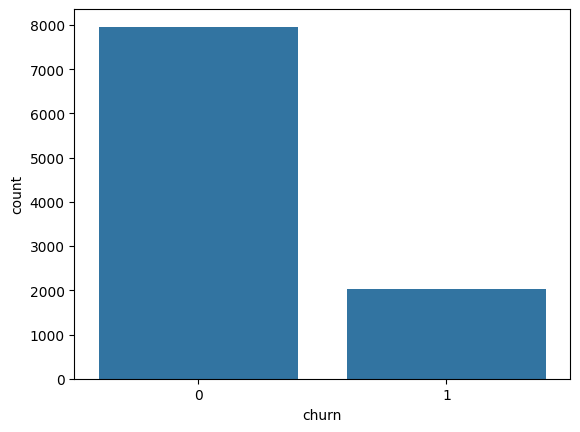

In [109]:
# Chcę zobaczyć rozkład wartości w kolumnie 'churn'
sns.countplot(x='churn', data=data)

Wniosek: Ze względu na niezbalansowanie klas (klientów odchodzących jest dużo mniej) musimy uważać podczas dzielenia danych na treningowe i testowe.

In [110]:
X = data.drop('churn', axis=1)
y = data['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=24)

In [111]:
to_remove = {'customer_id', 'credit_card', 'active_member', 'churn'}

num_cols = [col for col in numerical_cols if col not in to_remove]
print(num_cols)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']


In [112]:
oh_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

X_train_encoded = oh_encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = oh_encoder.transform(X_test[categorical_cols])

X_train_final = pd.concat([X_train.drop(categorical_cols, axis=1), X_train_encoded], axis=1)
X_test_final = pd.concat([X_test.drop(categorical_cols, axis=1), X_test_encoded], axis=1)

X_train_final.head()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain,gender_Female,gender_Male
1360,15694409,-0.037621,-1.609493,-0.690172,0.343357,0.806525,0,1,-0.660162,0.0,1.0,0.0,1.0,0.0
1536,15794014,1.937477,-0.470214,1.045564,-1.228366,0.806525,1,0,-1.260393,1.0,0.0,0.0,1.0,0.0
8779,15650322,0.520783,-0.470214,-0.690172,0.465482,-0.915439,0,1,-0.441451,1.0,0.0,0.0,1.0,0.0
2016,15633612,0.469079,-1.039854,-0.343025,1.541225,-0.915439,1,1,0.283056,1.0,0.0,0.0,0.0,1.0
2502,15782659,-1.278520,-0.660094,-1.731614,-1.228366,-0.915439,1,0,0.162570,1.0,0.0,0.0,0.0,1.0


### 3. EDA

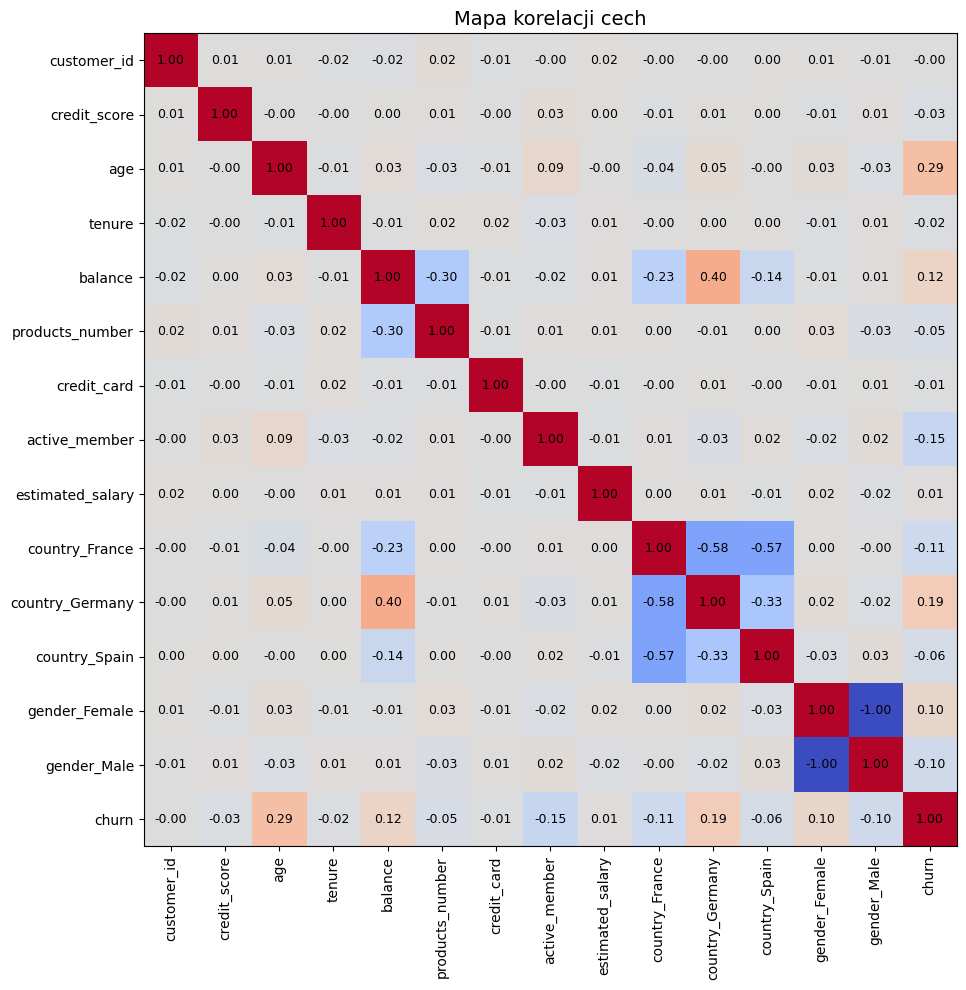

In [113]:
data_for_heatmap = X_train_final.join(y_train)
corr_matrix = data_for_heatmap.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

ticks = np.arange(len(corr_matrix.columns))
plt.xticks(ticks=ticks, labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=ticks, labels=corr_matrix.columns)
plt.title('Mapa korelacji cech', fontsize=14)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                 ha='center', va='center', color='black', fontsize=9)

plt.tight_layout()
plt.show()

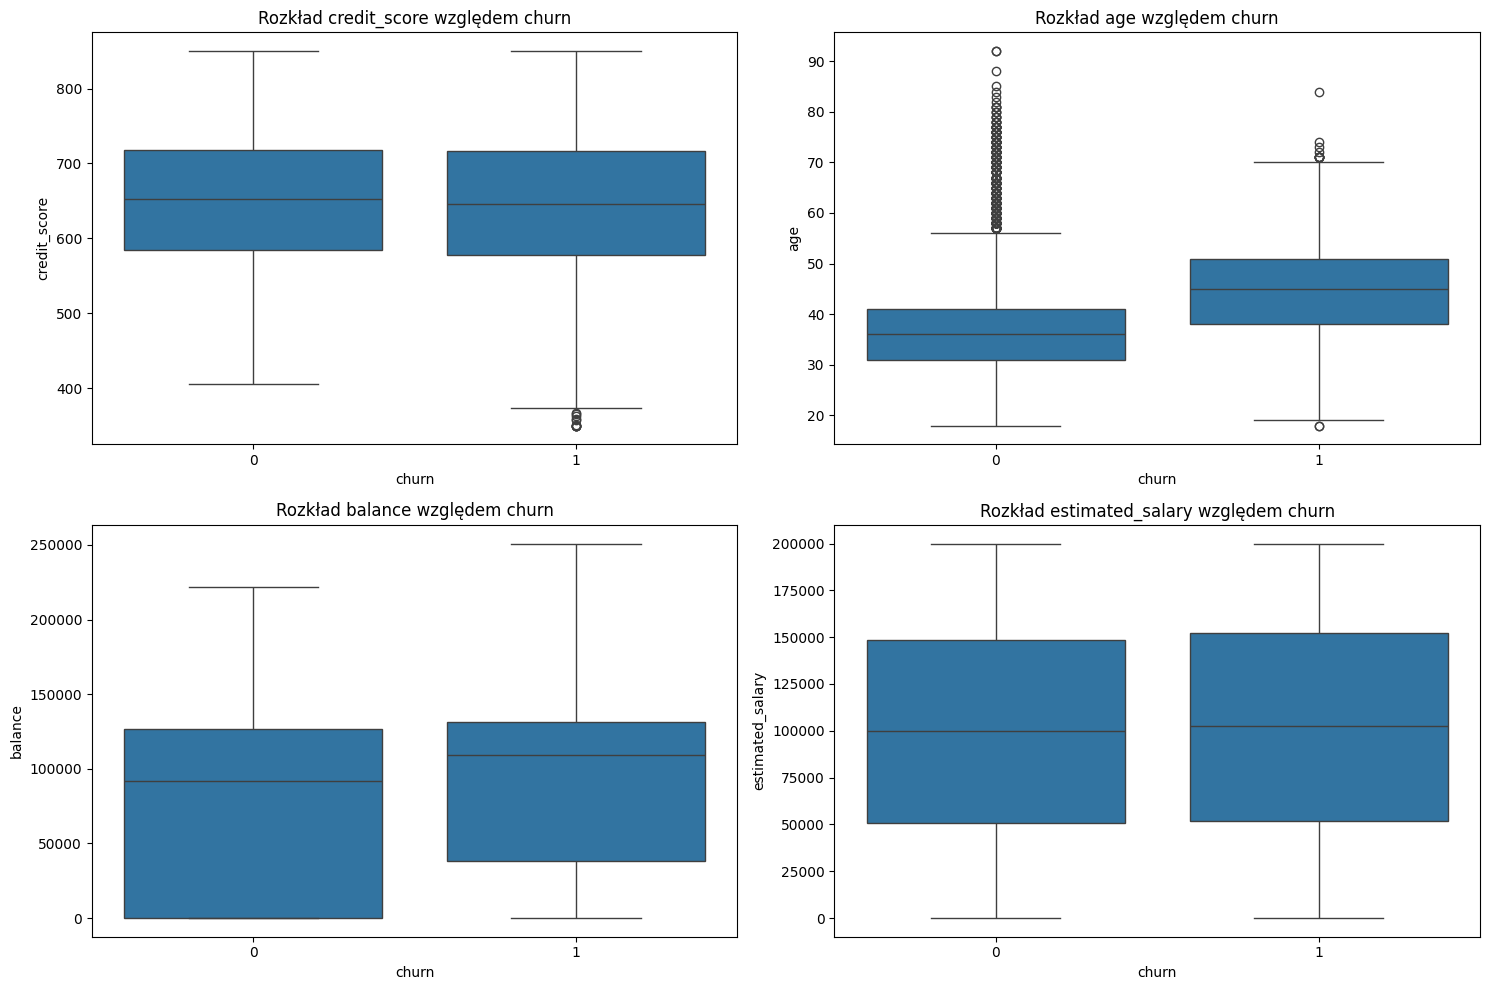

In [114]:
cols_to_plot = ['credit_score', 'age', 'balance', 'estimated_salary']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='churn', y=col, data=data)
    plt.title(f'Rozkład {col} względem churn')

plt.tight_layout()
plt.show()

In [115]:
# Robię SMOTE żeby zmniejszyć niezbalansowanie danych
smote = SMOTE(random_state=24)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

print(f"Przed SMOTE: {y_train.value_counts().to_dict()}")
print(f"Po SMOTE: {y_train_resampled.value_counts().to_dict()}")

X_train_final = X_train_resampled
y_train = y_train_resampled

Przed SMOTE: {0: 6370, 1: 1630}
Po SMOTE: {0: 6370, 1: 6370}


In [116]:
# rf_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 15, 20],
# }

# rf_grid_search = GridSearchCV(
#     estimator=RandomForestClassifier(class_weight='balanced', random_state=24),
#     param_grid=rf_param_grid,
#     scoring='roc_auc',
#     n_jobs=-1, # użyj wszystkich rdzeni CPU
# )

# rf_grid_search.fit(X_train_final, y_train)

# print(f"Najlepsze parametry: {rf_grid_search.best_params_}")

# rf_best_model = rf_grid_search.best_estimator_
# rf_predict = rf_best_model.predict(X_test_final)

# rf_result = classification_report(y_test, rf_predict)
# print('=' * 60)
# print(f'{' ' * 15}Random Forest results \n\n{rf_result}')
# print('=' * 60)

In [117]:
# ------------------- LogisticRegression -------------------
lr_model = LogisticRegression(random_state=24)
lr_model.fit(X_train_final, y_train)
lr_predict = lr_model.predict(X_test_final)

lr_result = classification_report(y_test, lr_predict)
print('=' * 60)
print(f'{' ' * 15}Logistic Regression results \n\n{lr_result}')
print('=' * 60)

# ------------------- RandomForestClassifier -------------------
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=24)
rf_model.fit(X_train_final, y_train)
rf_predict = rf_model.predict(X_test_final)

rf_result = classification_report(y_test, rf_predict)
print('=' * 60)
print(f'{' ' * 15}Random Forest results \n\n{rf_result}')
print('=' * 60)

# ------------------- XGBClassifier -------------------
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=24, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_final, y_train)
xgb_predict = xgb_model.predict(X_test_final)

xgb_result = classification_report(y_test, xgb_predict)
print('=' * 60)
print(f'{' ' * 15}XGB results \n\n{xgb_result}')
print('=' * 60)

               Logistic Regression results 

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1593
           1       0.40      0.67      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.70      0.65      2000
weighted avg       0.79      0.72      0.75      2000

               Random Forest results 

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.69      0.47      0.56       407

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.73      2000
weighted avg       0.84      0.85      0.84      2000

               XGB results 

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.69      0.51      0.59       407

    accuracy                           0.85      2000
   macro avg   

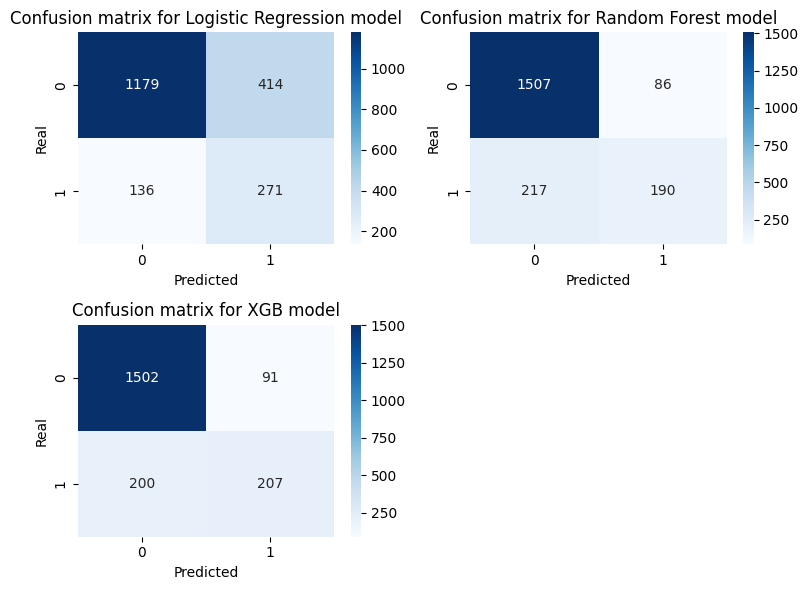

In [118]:
plt.figure(figsize=(8, 6))

plt.subplot(2, 2, 1)
sns.heatmap(confusion_matrix(y_test, lr_predict), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion matrix for Logistic Regression model')

plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test, rf_predict), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion matrix for Random Forest model')

plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, xgb_predict), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion matrix for XGB model')

plt.tight_layout()
plt.show()